# Extended Data Figure 5: Tracking jitter by 3D facial feature

To run this notebook, you need the following datasets:
- `/anipose-projects/20231013-long-anes-rig2`

In [1]:
%load_ext autoreload
%autoreload 2

# Update path as if notebook was run from top-level repo directory
import os
import sys

pwd = %pwd
if pwd.endswith('notebooks'):
    sys.path.insert(0, os.path.abspath('..'))
    new_pwd = os.path.abspath(f"{pwd}/..")
    %cd {new_pwd}

/data/disk2/irenenozal/mouse-fe-analysis


/home/irenenozal/micromamba/envs/mouse-fe-analysis/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import seaborn.objects as so
import matplotlib.pyplot as plt
from pathlib import Path
from functools import reduce

from fepipeline.features.landmarks import read_3d_data
from fepipeline.anatomy import compute_measurements_df
from labutils.plotting import (sns_setup,
                               landmark_cmap,
                               measurements_cmap,
                               save_figure)

sns_setup()
OUTPUT_DIR = "./figures/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# We didn't measure the amount of time between the end of the awake video and the anesthesia injection
# This adds a constant offset of 5 minutes for every mouse
AWAKE_END_OFFSET = 5*60

# Start of anesthesia video after injection (in seconds)
ANES_START_OFFSETS = {
    'B6': 120,
    'B8': 180,
    'B15': 60,
    'B20': 31,
    'B26': 53,
    'B33': 30,
}

STILL_PERIODS = {
    "B6": (38.50, 44.05),
    "B8": (34.30, 39.55),
    "B15": (27.20, 34.15),
    "B20": (34.55, 41.00),
    "B26": (58.20, 63.28),
    # "B33": (44.30, 50.05)
    # "C3": (0, None)
}

REGION_ORDER = ["eye(left)", "eye(right)",
                "ear(left)", "ear(right)",
                "nose", "whisker pad", "mouth"]

_, LANDMARK_CMAP = landmark_cmap()
_, MEASUREMENT_CMAP = measurements_cmap()

DATA_CACHE = "measurements-data-cache" 
os.makedirs(DATA_CACHE, exist_ok=True)
COORD_DATA_CACHE = os.sep.join([DATA_CACHE, "long-anes-jitter-coords.pkl"])
MEAS_DATA_CACHE = os.sep.join([DATA_CACHE, "long-anes-jitter-meas.pkl"])

ANIPOSE_BASE = 'anipose-projects/20231013-long-anes-rig2'
COORDINATE_PATHS = {}
key_cols = ('mouse', 'source', 'condition')
for p in Path(ANIPOSE_BASE).glob('*/pose-3d/*.csv'):
    mouse = p.name.split('_')[1]
    source = 'rig2'
    condition = 'awake' if 'awake' in p.name else 'anes'
    if condition == "awake":
        continue
    COORDINATE_PATHS[(mouse, source, condition)] = p
data_keys = list(COORDINATE_PATHS.keys())
data_keys

[('B26', 'rig2', 'anes'),
 ('B20', 'rig2', 'anes'),
 ('B8', 'rig2', 'anes'),
 ('B15', 'rig2', 'anes'),
 ('B33', 'rig2', 'anes'),
 ('B6', 'rig2', 'anes')]

## Load data

In [3]:
coord_data = {k: read_3d_data(v.parent.parent.as_posix())
              for k, v in COORDINATE_PATHS.items()}

# read in dead mice
# ANIPOSE_DEAD_BASE = "anipose-projects/20240325_C1-C2-C3-C4_jitter_rig2"
# coord_data[("C3", "rig2", "dead")] = read_3d_data(os.sep.join([
#     ANIPOSE_DEAD_BASE,
#     "20240325_C1-C2-C3-C4_jitter_rig2-C3-all-XXX"
# ]))

meas_df = compute_measurements_df(coord_data)
meas_df

,mouse,source,condition,measurement_group,measurement_name,measurement_units,measurement_type,measurement_value,std,count,timeseries
63,B15,rig2,anes,ear,ear-area-left,mm^2,area,78.012501,3.413662,453719,"[73.33781703086822, 73.31814044684096, 73.2949..."
62,B15,rig2,anes,ear,ear-angle-right,deg,angle,161.653493,2.004339,453719,"[158.9503560481014, 158.93508398647606, 158.92..."
67,B15,rig2,anes,cheek,cheek-bulge-volume,mm^3,volume,43.628303,1.989122,453719,"[42.8921384670557, 42.86318694155906, 42.83855..."
66,B15,rig2,anes,nose,nose-bulge-volume,mm^3,volume,7.348679,0.275826,453719,"[6.957967004950578, 6.994033793851652, 7.02169..."
65,B15,rig2,anes,mouth,mouth-area,mm^2,area,1.979067,0.196173,453719,"[1.6330489657917808, 1.6315368141250952, 1.631..."
...,...,...,...,...,...,...,...,...,...,...,...
46,B8,rig2,anes,ear,ear-area-left,mm^2,area,75.783488,1.261482,396570,"[77.57683130382541, 77.61146656434293, 77.6453..."
47,B8,rig2,anes,ear,ear-area-right,mm^2,area,78.494843,0.868175,396570,"[79.15804354957348, 79.23161238944319, 79.2941..."
48,B8,rig2,anes,mouth,mouth-area,mm^2,area,1.747887,0.078828,396570,"[1.8803684253954824, 1.8789482156667694, 1.876..."
42,B8,rig2,anes,ear,ear-width-left,mm,distance,7.148769,0.120801,396570,"[7.09780716415534, 7.09952034766652, 7.1016457..."


In [4]:
def build_jitter_df(coord_data, periods):
    jitter_df = []
    for mouse, period in periods.items():
        start = round(period[0] * 60 * 100) if period[0] is not None else None
        end = round(period[1] * 60 * 100) if period[1] is not None else None
        if (mouse, "rig2", "anes") in coord_data:
            positions = coord_data[(mouse, "rig2", "anes")]
        else:
            positions = coord_data[(mouse, "rig2", "dead")]
        for name, timeseries in positions.items():
            if "eye" in name:
                if "left" in name:
                    group = "eye(left)"
                else:
                    group = "eye(right)"
            elif "ear" in name:
                if "left" in name:
                    group = "ear(left)"
                else:
                    group = "ear(right)"
            elif "lip" in name:
                group = "mouth"
            elif "nose" in name:
                group = "nose"
            elif "pad" in name:
                group = "whisker pad"
            elif "ref" in name:
                continue
            else:
                raise ValueError(f"Cannot map {name} to landmark group.")
            for i, coord in enumerate(("x", "y", "z")):
                xs = timeseries[start:end, i]
                vs = np.abs(np.diff(xs)) * 100
                dev = (xs - np.mean(xs)) * 1000
                jitter_df.append([mouse, group, name, coord, xs, vs, dev,
                                  np.std(xs) * 1000, np.min(dev), np.max(dev),
                                  np.mean(vs), np.min(vs), np.max(vs)])
            # 3d deviations
            xs = timeseries[start:end]
            vs = np.linalg.norm(np.diff(xs, axis=0), axis=-1) * 100
            dev = np.linalg.norm(xs - np.mean(xs, axis=0), axis=-1) * 1000
            jitter_df.append([mouse, group, name, "vector", xs, vs, dev,
                              np.std(dev), np.min(dev), np.max(dev),
                              np.mean(vs), np.min(vs), np.max(vs)])

    jitter_df = pd.DataFrame(jitter_df, columns=["mouse",
                                                 "region",
                                                 "landmark",
                                                 "coordinate",
                                                 "positions",
                                                 "velocities",
                                                 "deviations",
                                                 "position_stddev",
                                                 "min_deviation",
                                                 "max_deviation",
                                                 "velocity_mean",
                                                 "min_velocity",
                                                 "max_velocity"])

    return jitter_df

jitter_df = build_jitter_df(coord_data, STILL_PERIODS)
jitter_df

,mouse,region,landmark,coordinate,positions,velocities,deviations,position_stddev,min_deviation,max_deviation,velocity_mean,min_velocity,max_velocity
0,B6,ear(left),ear(base)(left),x,"[12.717478373276606, 12.717948146696656, 12.71...","[0.046977342005050104, 0.05434987832728666, 0....","[5.296047991729225, 5.765821411779726, 6.30932...",11.663221,-46.219484,37.030101,0.086942,0.000009,0.502900
1,B6,ear(left),ear(base)(left),y,"[19.469076460720924, 19.46803409450009, 19.466...","[0.10423662208332019, 0.10936332786499747, 0.1...","[8.354998061278707, 7.312631840445505, 6.21899...",10.481071,-38.796982,39.939237,0.093848,0.000006,0.451933
2,B6,ear(left),ear(base)(left),z,"[-3.489799297691393, -3.490289334560794, -3.49...","[0.04900368694009671, 0.022055184258817917, 0....","[-19.220671558761282, -19.71070842816225, -19....",8.824348,-34.536999,37.748417,0.068460,0.000004,0.333445
3,B6,ear(left),ear(base)(left),vector,"[[12.717478373276606, 19.469076460720924, -3.4...","[0.12439254551187286, 0.12409946780138989, 0.1...","[21.61685296480234, 21.799800634963027, 21.811...",7.366475,0.304461,52.830196,0.164848,0.004825,0.618729
4,B6,ear(right),ear(base)(right),x,"[22.741200729182594, 22.740101989289712, 22.73...","[0.10987398928818948, 0.12370711067113405, 0.1...","[6.510761260571485, 5.41202136768959, 4.174950...",6.739546,-26.798902,26.609062,0.066639,0.000003,0.407991
...,...,...,...,...,...,...,...,...,...,...,...,...,...
535,B26,mouth,upperlip(left),vector,"[[-1.9379050105137807, -5.09813185550081, 21.4...","[0.08321917573870498, 0.06488009153900923, 0.0...","[11.7789990003664, 12.16399894019403, 12.44205...",13.091409,0.597046,141.608559,0.144948,0.003030,0.973767
536,B26,mouth,upperlip(right),x,"[2.3467340004792563, 2.3456967546873977, 2.344...","[0.10372457918585987, 0.10040595188018919, 0.0...","[1.022696875515372, -0.014548916343226637, -1....",7.200103,-24.829219,26.693768,0.046576,0.000002,0.260156
537,B26,mouth,upperlip(right),y,"[-5.224003676692099, -5.223853480757391, -5.22...","[0.015019593470810833, 0.014928468814900953, 0...","[2.445984694730008, 2.5961806294381162, 2.7454...",15.749506,-60.368896,45.219034,0.046247,0.000003,0.477975
538,B26,mouth,upperlip(right),z,"[21.229670252932152, 21.229979191181677, 21.23...","[0.030893824952471505, 0.02055208448403789, 0....","[11.876217928037391, 12.185156177562106, 12.39...",8.211574,-33.148845,26.538244,0.036414,0.000002,0.277028


In [5]:
# check for deviations larger than 50 microns
jitter_df.query("position_stddev > 50")

,mouse,region,landmark,coordinate,positions,velocities,deviations,position_stddev,min_deviation,max_deviation,velocity_mean,min_velocity,max_velocity
9,B6,ear(left),ear(bottom)(left),y,"[26.47725876715757, 26.4915000809574, 26.50399...","[1.4241313799832511, 1.249727781970833, 1.0175...","[26.690768703815593, 40.932082503648104, 53.42...",64.342155,-116.721592,184.592396,0.562537,0.000007,2.428458
10,B6,ear(left),ear(bottom)(left),z,"[-5.240666334279743, -5.248971058862848, -5.25...","[0.8304724583105383, 0.7213984879879121, 0.581...","[-59.43223078710247, -67.73695537020785, -74.9...",57.352175,-159.107889,125.999118,0.464277,0.000076,1.874707
12,B6,ear(right),ear(bottom)(right),x,"[30.37415447462675, 30.356703941972484, 30.342...","[1.7450532654265771, 1.435617309411441, 1.0543...","[-14.568585827007041, -32.01911848127281, -46....",93.530268,-137.085477,252.039130,0.865522,0.000036,3.262157
13,B6,ear(right),ear(bottom)(right),y,"[-1.8149455211854464, -1.827734440350348, -1.8...","[1.2788919164901547, 1.097159032131123, 0.8810...","[-21.25443451116782, -34.043353676069366, -45....",73.662925,-155.081572,209.388058,0.599392,0.000026,2.459525
15,B6,ear(right),ear(bottom)(right),vector,"[[30.37415447462675, -1.8149455211854464, 2.08...","[2.17004633589083, 1.8160152860231533, 1.38638...","[38.00314990516851, 53.60249871670818, 69.0925...",58.898509,0.893941,328.374076,1.109439,0.007768,3.852417


## Only for reference: Fig 2

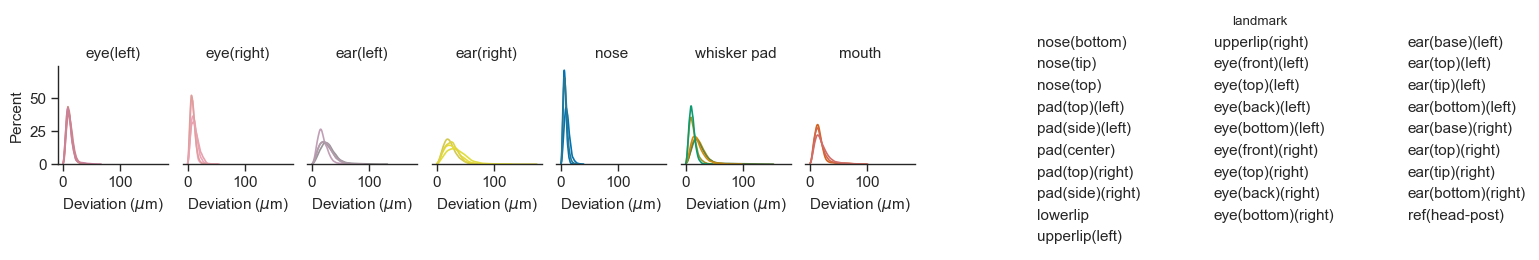

In [6]:
def plot_histogram(deviations, color, label):
    sns.histplot(x=np.concatenate(deviations.values, axis=0),
                 color=LANDMARK_CMAP[label],
                 label=label,
                 kde=True,
                 stat="percent",
                 binwidth=5,
                 # hack to hide bars but keep percent y-axis
                 fill=False,
                 linewidth=0)
    # sns.kdeplot(x=np.concatenate(deviations.values, axis=0),
    #             color=LANDMARK_CMAP[label],
    #             label=label)

ncols = len(jitter_df["region"].unique())
total_width = 2 * 5 # inches
facet_width = total_width / ncols
total_height = 2
aspect = facet_width / total_height
g = sns.FacetGrid(jitter_df.query("mouse == 'B15' & coordinate =='vector'"),
                  col="region", hue="landmark",
                  col_order=REGION_ORDER,
                #   col_wrap=2,
                #   xlim=(-100, 100),
                #   ylim=(0, 2),
                  height=total_height,
                  aspect=aspect,
                #   subplot_kws={"width": 0.5},
                  margin_titles=True)
g.map(plot_histogram, "deviations")
g.add_legend(label_order=list(LANDMARK_CMAP.keys()), ncols=3)
# g.figure.suptitle("Coordinate-wise Deviation from Mean Landmark Position")
g.set_xlabels("Deviation ($\mu$m)")
g.set_titles(col_template="{col_name}")
g.tight_layout(w_pad=0.5)
for ax in g.axes.flat[1:]:
    sns.despine(ax=ax, left=True)
    ax.tick_params(axis="y", left=False)

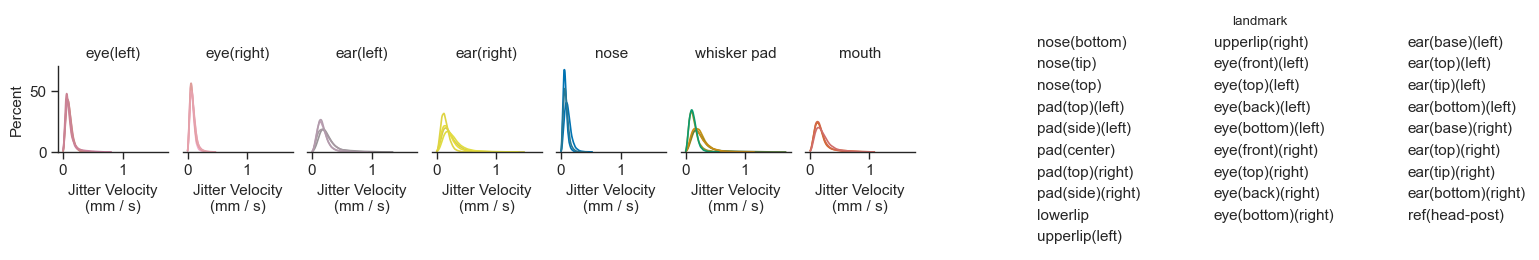

In [7]:
def plot_histogram(deviations, color, label):
    sns.histplot(x=np.concatenate(deviations.values, axis=0),
                 color=LANDMARK_CMAP[label],
                 label=label,
                 kde=True,
                 stat="percent",
                 binwidth=0.05,
                 # hack to hide bars but keep percent y-axis
                 fill=False,
                 linewidth=0)
    # sns.kdeplot(x=np.concatenate(deviations.values, axis=0),
    #             color=LANDMARK_CMAP[label],
    #             label=label)

ncols = len(jitter_df["region"].unique())
total_width = 2 * 5 # inches
facet_width = total_width / ncols
total_height = 2
aspect = facet_width / total_height
g = sns.FacetGrid(jitter_df.query("mouse == 'B15' & coordinate =='vector'"),
                  col="region", hue="landmark",
                  col_order=REGION_ORDER,
                #   col_wrap=2,
                #   xlim=(-100, 100),
                #   ylim=(0, 2),
                  height=total_height,
                  aspect=aspect,
                #   subplot_kws={"width": 0.5},
                  margin_titles=True)
g.map(plot_histogram, "velocities")
g.add_legend(label_order=list(LANDMARK_CMAP.keys()), ncols=3)
# g.figure.suptitle("Coordinate-wise Deviation from Mean Landmark Position")
g.set_xlabels("Jitter Velocity\n(mm / s)")
g.set_titles(col_template="{col_name}")
g.tight_layout(w_pad=0.5)
for ax in g.axes.flat[1:]:
    sns.despine(ax=ax, left=True)
    ax.tick_params(axis="y", left=False)
save_figure(OUTPUT_DIR, "long-anes-a-jitter-hist", g.figure)

In [8]:
def sort_by_region(df, region_order, *columns):
    df.loc[:, "region_rank"] = df["region"].transform(lambda x: region_order.index(x))
    df = df.sort_values(by=["region_rank", *columns])
    df = df.drop(columns=["region_rank"])

    return df

sort_by_region(jitter_df, REGION_ORDER, "landmark")

,mouse,region,landmark,coordinate,positions,velocities,deviations,position_stddev,min_deviation,max_deviation,velocity_mean,min_velocity,max_velocity
32,B6,eye(left),eye(back)(left),x,"[9.129499280189364, 9.128376854238738, 9.12735...","[0.11224259506263934, 0.10183772405696345, 0.0...","[0.3060885899692778, -0.8163373606571156, -1.8...",5.707187,-20.814495,24.533573,0.049944,1.380609e-06,0.257068
33,B6,eye(left),eye(back)(left),y,"[10.868527470619458, 10.869041540220532, 10.86...","[0.05140696010741408, 0.03938714471232174, 0.0...","[3.592321683777655, 4.106391284851796, 4.50026...",5.292874,-17.769484,24.846166,0.043677,1.136934e-06,0.279317
34,B6,eye(left),eye(back)(left),z,"[-5.5564246924574565, -5.558536690776288, -5.5...","[0.2111998318831354, 0.20324133253133425, 0.18...","[-4.835702259247121, -6.947700578078475, -8.98...",6.650198,-25.602639,21.980194,0.052098,6.125312e-07,0.311887
35,B6,eye(left),eye(back)(left),vector,"[[9.129499280189364, 10.868527470619458, -5.55...","[0.24463532999414772, 0.23071477728746373, 0.2...","[6.031789257268791, 8.111682895212912, 10.2108...",4.074767,0.360185,29.538615,0.096964,4.272239e-03,0.370002
140,B8,eye(left),eye(back)(left),x,"[-6.2518892459090765, -6.252838192210227, -6.2...","[0.09489463011504995, 0.10360924593726395, 0.1...","[-4.070563731714216, -5.019510032864716, -6.05...",14.718200,-35.163399,62.983161,0.112193,1.845456e-05,0.606548
...,...,...,...,...,...,...,...,...,...,...,...,...,...
431,B20,mouth,upperlip(right),vector,"[[1.555601703040567, -3.718893861521529, 21.90...","[0.04198757700534949, 0.05424683254330767, 0.0...","[7.704600755700586, 7.300655749152415, 6.76381...",7.293507,0.430524,63.169748,0.079470,3.373665e-03,0.549424
536,B26,mouth,upperlip(right),x,"[2.3467340004792563, 2.3456967546873977, 2.344...","[0.10372457918585987, 0.10040595188018919, 0.0...","[1.022696875515372, -0.014548916343226637, -1....",7.200103,-24.829219,26.693768,0.046576,1.921015e-06,0.260156
537,B26,mouth,upperlip(right),y,"[-5.224003676692099, -5.223853480757391, -5.22...","[0.015019593470810833, 0.014928468814900953, 0...","[2.445984694730008, 2.5961806294381162, 2.7454...",15.749506,-60.368896,45.219034,0.046247,2.519496e-06,0.477975
538,B26,mouth,upperlip(right),z,"[21.229670252932152, 21.229979191181677, 21.23...","[0.030893824952471505, 0.02055208448403789, 0....","[11.876217928037391, 12.185156177562106, 12.39...",8.211574,-33.148845,26.538244,0.036414,1.531794e-06,0.277028


In [9]:
def compute_dodges(df, x, hue, gap = 0.1):
    subgroups = df.groupby(x)[hue].unique().values
    dodges = {}
    for subgroup in subgroups:
        count = len(subgroup)
        if count == 1:
            shifts = [0]
        elif count == 2:
            shifts = [-1, 1]
        else:
            shifts = [*np.linspace(start=-count / 2, stop=count / 2, num=count)]
        for name, shift in zip(subgroup, shifts):
            dodges[name] = shift * gap

    dodge_df = df[[x, hue]].copy()
    dodge_df["dodge"] = df.groupby(x)[hue].transform(lambda x: [dodges[xi] for xi in x])

    return dodge_df

compute_dodges(jitter_df.query("coordinate == 'vector'"), "region", "landmark")

,region,landmark,dodge
3,ear(left),ear(base)(left),-0.200000
7,ear(right),ear(base)(right),-0.200000
11,ear(left),ear(bottom)(left),-0.066667
15,ear(right),ear(bottom)(right),-0.066667
19,ear(left),ear(tip)(left),0.066667
...,...,...,...
523,whisker pad,pad(side)(right),0.000000
527,whisker pad,pad(top)(left),0.125000
531,whisker pad,pad(top)(right),0.250000
535,mouth,upperlip(left),0.000000


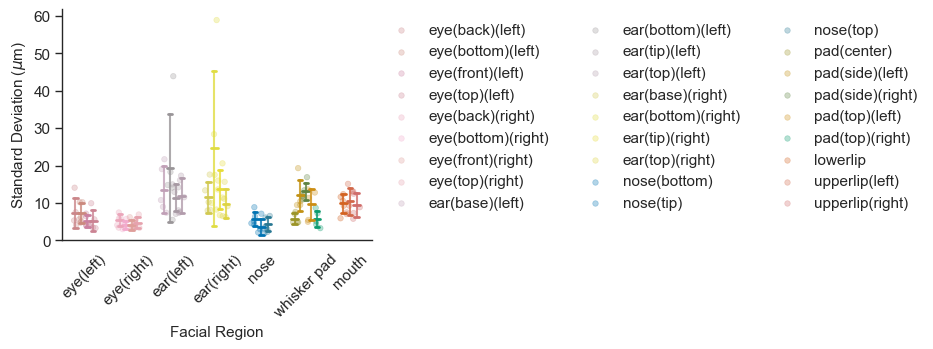

In [10]:
fig, ax = plt.subplots(figsize=(4, 3))

# sort the data by region and compute manual dodge factors
sub_df = jitter_df.query("mouse.str.startswith('B') & coordinate == 'vector'")
sub_df = sort_by_region(sub_df, REGION_ORDER, "landmark")
hue_order = sub_df.drop_duplicates("landmark")["landmark"].values

dodges = compute_dodges(sub_df, x="region", hue="landmark", gap=0.1)
dodge_shift = so.Shift(x=dodges["dodge"])
dodges_agg = dodges.drop_duplicates("landmark")
dodge_shift_agg = so.Shift(x=dodges_agg["dodge"].values)

p = (so.Plot(sub_df, x="region", y="position_stddev", color="landmark")
        # plot scatter of samples
        .add(so.Dot(pointsize=4, alpha=0.3), dodge_shift, so.Jitter())
        # plot mean bar
        .add(so.Dash(linewidth=2, width=0.15), so.Agg(), dodge_shift_agg)
        # plot stddev whiskers
        .add(so.Dash(linewidth=2, width=0.1),
             so.Agg(lambda x: x.mean() + x.std(ddof=1)),
             dodge_shift_agg)
        .add(so.Dash(linewidth=2, width=0.1),
             so.Agg(lambda x: x.mean() - x.std(ddof=1)),
             dodge_shift_agg)
        # connect mean to whiskers (stddev range)
        .add(so.Range(alpha=0.8), so.Est(errorbar="sd"), dodge_shift_agg)
        .theme({"axes.prop_cycle": plt.cycler(color=[LANDMARK_CMAP[l] for l in hue_order])})
        .on(ax).plot())

# sort the data by region and compute manual dodge factors
# sub_df = jitter_df.query("mouse.str.startswith('C') & coordinate == 'vector'")
# sub_df = sort_by_region(sub_df, REGION_ORDER, "landmark")
# hue_order = sub_df.drop_duplicates("landmark")["landmark"].values

# dodges = compute_dodges(sub_df, x="region", hue="landmark", gap=0.1)
# dodge_shift = so.Shift(x=dodges["dodge"])
# # dodges_agg = dodges.drop_duplicates("landmark")
# # dodge_shift_agg = so.Shift(x=dodges_agg["dodge"].values)

# p = (so.Plot(sub_df, x="region", y="position_stddev", color="landmark")
#         # plot scatter of samples
#         .add(so.Dot(marker="x"), dodge_shift, legend=False)
#         # plot mean bar
#         # .add(so.Dash(linewidth=2, width=0.15), so.Agg(), dodge_shift_agg)
#         # plot stddev whiskers
#         # .add(so.Dash(linewidth=2, width=0.1),
#         #      so.Agg(lambda x: x.mean() + x.std()),
#         #      dodge_shift_agg)
#         # .add(so.Dash(linewidth=2, width=0.1),
#         #      so.Agg(lambda x: x.mean() - x.std()),
#         #      dodge_shift_agg)
#         # connect mean to whiskers (stddev range)
#         # .add(so.Range(alpha=0.8), so.Est(errorbar="sd"), dodge_shift_agg)
#         .theme({"axes.prop_cycle": plt.cycler(color=[LANDMARK_CMAP[l] for l in hue_order])})
#         .on(ax).plot())

ax.set_xlabel("Facial Region")
ax.set_ylabel("Standard Deviation ($\mu$m)")
ax.tick_params(axis="x", rotation=45, bottom=False)
ax.set_ylim(0, None)
# hack to customize legends with seaborn objects interface
legend = fig.legends.pop(0)
ax.legend(legend.legend_handles, [t.get_text() for t in legend.texts],
          ncols=3, frameon=False, bbox_to_anchor=(1.0, 1.0))
sns.despine(fig)

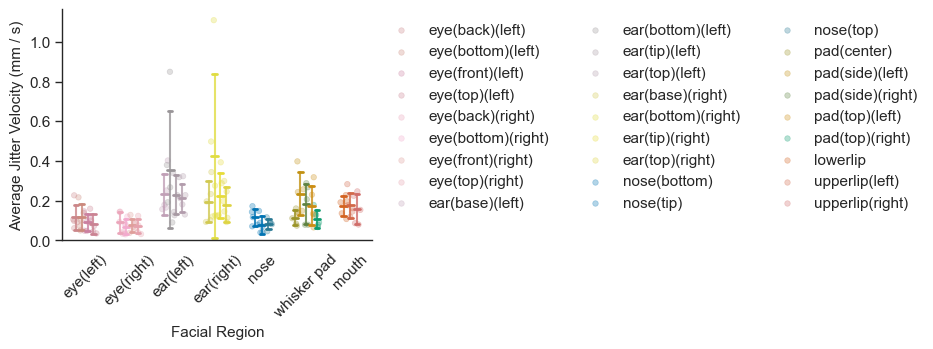

In [11]:
fig, ax = plt.subplots(figsize=(4, 3))

# sort the data by region and compute manual dodge factors
sub_df = jitter_df.query("mouse.str.startswith('B') & coordinate == 'vector'")
sub_df = sort_by_region(sub_df, REGION_ORDER, "landmark")
hue_order = sub_df.drop_duplicates("landmark")["landmark"].values

dodges = compute_dodges(sub_df, x="region", hue="landmark", gap=0.1)
dodge_shift = so.Shift(x=dodges["dodge"])
dodges_agg = dodges.drop_duplicates("landmark")
dodge_shift_agg = so.Shift(x=dodges_agg["dodge"].values)

p = (so.Plot(sub_df, x="region", y="velocity_mean", color="landmark")
        # plot scatter of samples
        .add(so.Dot(pointsize=4, alpha=0.3), dodge_shift, so.Jitter())
        # plot mean bar
        .add(so.Dash(linewidth=2, width=0.15), so.Agg(), dodge_shift_agg)
        # plot stddev whiskers
        .add(so.Dash(linewidth=2, width=0.1),
             so.Agg(lambda x: x.mean() + x.std(ddof=1)),
             dodge_shift_agg)
        .add(so.Dash(linewidth=2, width=0.1),
             so.Agg(lambda x: x.mean() - x.std(ddof=1)),
             dodge_shift_agg)
        # connect mean to whiskers (stddev range)
        .add(so.Range(alpha=0.8), so.Est(errorbar="sd"), dodge_shift_agg)
        .theme({"axes.prop_cycle": plt.cycler(color=[LANDMARK_CMAP[l] for l in hue_order])})
        .on(ax).plot())

# sort the data by region and compute manual dodge factors
# sub_df = jitter_df.query("mouse.str.startswith('C') & coordinate == 'vector'")
# sub_df = sort_by_region(sub_df, REGION_ORDER, "landmark")
# hue_order = sub_df.drop_duplicates("landmark")["landmark"].values

# dodges = compute_dodges(sub_df, x="region", hue="landmark", gap=0.1)
# dodge_shift = so.Shift(x=dodges["dodge"])
# # dodges_agg = dodges.drop_duplicates("landmark")
# # dodge_shift_agg = so.Shift(x=dodges_agg["dodge"].values)

# p = (so.Plot(sub_df, x="region", y="velocity_stddev", color="landmark")
#         # plot scatter of samples
#         .add(so.Dot(marker="x"), dodge_shift, legend=False)
#         # plot mean bar
#         # .add(so.Dash(linewidth=2, width=0.15), so.Agg(), dodge_shift_agg)
#         # plot stddev whiskers
#         # .add(so.Dash(linewidth=2, width=0.1),
#         #      so.Agg(lambda x: x.mean() + x.std()),
#         #      dodge_shift_agg)
#         # .add(so.Dash(linewidth=2, width=0.1),
#         #      so.Agg(lambda x: x.mean() - x.std()),
#         #      dodge_shift_agg)
#         # connect mean to whiskers (stddev range)
#         # .add(so.Range(alpha=0.8), so.Est(errorbar="sd"), dodge_shift_agg)
#         .theme({"axes.prop_cycle": plt.cycler(color=[LANDMARK_CMAP[l] for l in hue_order])})
#         .on(ax).plot())

ax.set_xlabel("Facial Region")
ax.set_ylabel("Average Jitter Velocity (mm / s)")
ax.tick_params(axis="x", rotation=45, bottom=False)
ax.set_ylim(0, None)
# hack to customize legends with seaborn objects interface
legend = fig.legends.pop(0)
ax.legend(legend.legend_handles, [t.get_text() for t in legend.texts],
          ncols=3, frameon=False, bbox_to_anchor=(1.0, 1.0))
sns.despine(fig)
save_figure(OUTPUT_DIR, "long-anes-b-keypoint-jitter-summary", fig)

In [12]:
stats_df = jitter_df.query("coordinate == 'vector'")[["mouse", "landmark", "velocity_mean"]].pivot(
    columns="landmark", index="mouse"
)
# stats_df.to_clipboard(excel=True)
stats_df


velocity_mean                                     \
landmark ear(base)(left) ear(base)(right) ear(bottom)(left)   
mouse                                                         
B15             0.179080         0.233366          0.267036   
B20             0.251265         0.101985          0.089990   
B26             0.156896         0.092676          0.191686   
B6              0.164848         0.196024          0.849284   
B8              0.402257         0.343859          0.379460   

                                                                           \
landmark ear(bottom)(right) ear(tip)(left) ear(tip)(right) ear(top)(left)   
mouse                                                                       
B15                0.275281       0.226825        0.197448       0.180738   
B20                0.125790       0.125999        0.127631       0.130186   
B26                0.120199       0.142791        0.121430       0.227569   
B6                 1.109439       0.318413        0.393017       0.211914   
B8                 0.497847       0.338988        0.287390       0.323021   

                                                           ...               \
landmark ear(top)(right) eye(back)(left) eye(back)(right)  ... nose(bottom)   
mouse                                                      ...                
B15             0.145529        0.105022         0.092341  ...     0.116696   
B20             0.092093        0.091834         0.043104  ...     0.078628   
B26             0.113037        0.061182         0.033624  ...     0.070405   
B6              0.245987        0.096964         0.143001  ...     0.171937   
B8              0.299015        0.226597         0.144498  ...     0.142894   

                                                                           \
landmark nose(tip) nose(top) pad(center) pad(side)(left) pad(side)(right)   
mouse                                                                       
B15       0.069900  0.085296    0.139759        0.243196         0.267362   
B20       0.041742  0.091504    0.084120        0.148639         0.078397   
B26       0.038968  0.045463    0.073685        0.131968         0.078568   
B6        0.087961  0.081047    0.110975        0.257175         0.206262   
B8        0.148099  0.116023    0.160436        0.397821         0.287702   

                                                                        
landmark pad(top)(left) pad(top)(right) upperlip(left) upperlip(right)  
mouse                                                                   
B15            0.229691        0.128397       0.176939        0.224346  
B20            0.133481        0.066861       0.118000        0.079470  
B26            0.064973        0.078277       0.144948        0.086089  
B6             0.128882        0.089492       0.161989        0.153414  
B8             0.317818        0.178224       0.282953        0.246684  

[5 rows x 27 columns]

In [13]:
# jitter_df.to_pickle(COORD_DATA_CACHE)

In [14]:
def build_measjitter_df(meas_df, periods):
    # select only the subset of rows that match the mouse/source/condition pairs
    queries = [(meas_df["mouse"] == mouse) &
               (meas_df["source"] == "rig2") &
               ((meas_df["condition"] == "anes") | (meas_df["condition"] == "dead"))
               for mouse in periods.keys()]
    sub_df = meas_df[reduce(lambda x, y: x | y, queries)]
    jitter_df = sub_df[[*key_cols,
                        "measurement_group",
                        "measurement_name",
                        "measurement_type",
                        "timeseries"]]
    jitter_df = jitter_df.rename(columns={"measurement_group": "region"})
    jitter_df.loc[(jitter_df["region"] == 'eye') &
                  (jitter_df["measurement_name"].str.contains('left')), "region"] = "eye(left)"
    jitter_df.loc[(jitter_df["region"] == 'eye') &
                  (jitter_df["measurement_name"].str.contains('right')), "region"] = "eye(right)"
    jitter_df.loc[(jitter_df["region"] == 'ear') &
                  (jitter_df["measurement_name"].str.contains('left')), "region"] = "ear(left)"
    jitter_df.loc[(jitter_df["region"] == 'ear') &
                  (jitter_df["measurement_name"].str.contains('right')), "region"] = "ear(right)"
    jitter_df.loc[(jitter_df["region"] == "cheek"), "region"] = "whisker pad"
    jitter_df.loc[(jitter_df["measurement_name"] == "cheek-bulge-volume"), "measurement_name"] = "whisker-pad-bulge"
    jitter_df.loc[(jitter_df["measurement_name"] == "nose-bulge-volume"), "measurement_name"] = "nose-bulge"
    for mouse, period in periods.items():
        start = round(period[0] * 60 * 100) if period[0] is not None else None
        end = round(period[1] * 60 * 100) if period[1] is not None else None
        idx = jitter_df["mouse"] == mouse
        jitter_df.loc[idx, "timeseries"] = jitter_df.loc[idx, "timeseries"].apply(
            lambda x: x[start:end]
        )
    jitter_df["deviations"] = jitter_df.groupby("measurement_name")["timeseries"].transform(
        lambda x: x.apply(lambda xi: xi - xi.mean())
    )
    jitter_df["timeseries_stddev"] = jitter_df.groupby("measurement_name")["deviations"].transform(
        lambda x: x.apply(np.std)
    )
    jitter_df["min_deviation"] = jitter_df.groupby("measurement_name")["deviations"].transform(
        lambda x: x.apply(np.min)
    )
    jitter_df["max_deviation"] = jitter_df.groupby("measurement_name")["deviations"].transform(
        lambda x: x.apply(np.max)
    )
    jitter_df["velocities"] = jitter_df.groupby("measurement_name")["timeseries"].transform(
        lambda x: x.apply(lambda xi: np.abs(np.diff(xi))) * 100
    )
    jitter_df["velocity_mean"] = jitter_df.groupby("measurement_name")["velocities"].transform(
        lambda x: x.apply(np.mean)
    )
    jitter_df["velocity_thresh"] = jitter_df.groupby("measurement_name")["velocities"].transform(
        lambda x: x.apply(lambda xi: np.percentile(xi, 99.9))
    )
    jitter_df["min_velocity"] = jitter_df.groupby("measurement_name")["velocities"].transform(
        lambda x: x.apply(np.min)
    )
    jitter_df["max_velocity"] = jitter_df.groupby("measurement_name")["velocities"].transform(
        lambda x: x.apply(np.max)
    )
    jitter_df["deviations_au"] = jitter_df.groupby("measurement_name")["timeseries"].transform(
        lambda x: x.apply(lambda xi: (xi - xi.mean()) / xi.mean())
    )
    jitter_df["timeseries_stddev_au"] = jitter_df.groupby("measurement_name")["deviations_au"].transform(
        lambda x: x.apply(np.std)
    )
    jitter_df["min_deviation_au"] = jitter_df.groupby("measurement_name")["deviations_au"].transform(
        lambda x: x.apply(np.min)
    )
    jitter_df["max_deviation_au"] = jitter_df.groupby("measurement_name")["deviations_au"].transform(
        lambda x: x.apply(np.max)
    )
    jitter_df["velocities_au"] = jitter_df.groupby("measurement_name")["timeseries"].transform(
        lambda x: x.apply(lambda xi: np.abs(np.diff(xi)) / np.mean(np.abs(np.diff(xi))))
    )
    jitter_df["velocity_mean_au"] = jitter_df.groupby("measurement_name")["velocities_au"].transform(
        lambda x: x.apply(np.mean)
    )
    jitter_df["min_velocity_au"] = jitter_df.groupby("measurement_name")["velocities_au"].transform(
        lambda x: x.apply(np.min)
    )
    jitter_df["max_velocity_au"] = jitter_df.groupby("measurement_name")["velocities_au"].transform(
        lambda x: x.apply(np.max)
    )

    return jitter_df

meas_jitter_df = build_measjitter_df(meas_df, STILL_PERIODS)
meas_jitter_df

,mouse,source,condition,region,measurement_name,measurement_type,timeseries,deviations,timeseries_stddev,min_deviation,...,min_velocity,max_velocity,deviations_au,timeseries_stddev_au,min_deviation_au,max_deviation_au,velocities_au,velocity_mean_au,min_velocity_au,max_velocity_au
63,B15,rig2,anes,ear(left),ear-area-left,area,"[79.52336621092384, 79.53037652834092, 79.5374...","[-0.06336718349487569, -0.05635686607779178, -...",0.148666,-0.556684,...,1.703138e-05,7.055931,"[-0.0007962028442710218, -0.000708118849387830...",0.001868,-0.006995,0.007637,"[0.550821470416726, 0.5587906789331122, 0.5844...",1.0,0.000013,5.544054
62,B15,rig2,anes,ear(right),ear-angle-right,angle,"[162.47281537663105, 162.47260637999483, 162.4...","[-0.028168736088900914, -0.028377732725118676,...",0.099837,-0.442437,...,1.486254e-05,6.132596,"[-0.00017334501844838967, -0.00017463114380546...",0.000614,-0.002723,0.003069,"[0.026993629063163015, 0.05190281556803436, 0....",1.0,0.000019,7.920750
67,B15,rig2,anes,whisker pad,whisker-pad-bulge,volume,"[42.26853499067816, 42.25399124857385, 42.2408...","[-0.06236500239928944, -0.07690874450360496, -...",0.207711,-0.610915,...,9.152633e-06,13.594908,"[-0.0014732737175323048, -0.001816846429350242...",0.004907,-0.014432,0.024722,"[0.8323540638847832, 0.7520382609812803, 0.601...",1.0,0.000005,7.780513
66,B15,rig2,anes,nose,nose-bulge,volume,"[7.536511604850552, 7.535017243292458, 7.53314...","[0.020770822527471644, 0.01927646096937785, 0....",0.054611,-0.291684,...,6.034978e-06,4.473689,"[0.0027636427504690335, 0.0025648118432604573,...",0.007266,-0.038810,0.023492,"[0.3059662807443723, 0.3827948124220206, 0.449...",1.0,0.000012,9.159750
65,B15,rig2,anes,mouth,mouth-area,area,"[2.0596416725456748, 2.0589983216976275, 2.058...","[0.011321157090633083, 0.010677806242585852, 0...",0.018121,-0.084752,...,2.409616e-05,1.166512,"[0.0055270437439904506, 0.00521295674286294, 0...",0.008847,-0.041376,0.033846,"[0.38728665716863714, 0.31870074210971555, 0.2...",1.0,0.000145,7.022208
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46,B8,rig2,anes,ear(left),ear-area-left,area,"[75.2667206160364, 75.18195389920075, 75.09676...","[0.11629024009974387, 0.031523523264098685, -0...",0.277889,-0.717121,...,4.066834e-05,13.864538,"[0.0015474327893800098, 0.0004194722918605213,...",0.003698,-0.009542,0.016427,"[3.1531111468846533, 3.168939980682803, 3.0825...",1.0,0.000015,5.157263
47,B8,rig2,anes,ear(right),ear-area-right,area,"[77.82512922689651, 77.80276725628465, 77.7830...","[0.24454759801839998, 0.2221856274065459, 0.20...",0.206780,-0.880115,...,5.704868e-05,13.031471,"[0.0031521753624926567, 0.0028639335094110836,...",0.002665,-0.011345,0.012199,"[1.2335290251141817, 1.0901976550660075, 0.904...",1.0,0.000031,7.188408
48,B8,rig2,anes,mouth,mouth-area,area,"[1.7557090082471103, 1.7542494850805523, 1.753...","[-0.030231742210773627, -0.03169126537733158, ...",0.025167,-0.118050,...,1.722540e-06,2.193830,"[-0.016927628871799213, -0.017744858203838226,...",0.014092,-0.066100,0.074165,"[0.5759631980664283, 0.3018849121421859, 0.008...",1.0,0.000007,8.657384
42,B8,rig2,anes,ear(left),ear-width-left,distance,"[7.109418645580339, 7.106675952806058, 7.10396...","[0.016731708638464404, 0.01398901586418333, 0....",0.018118,-0.062233,...,2.193929e-07,1.029637,"[0.002359008481160815, 0.001972315426939585, 0...",0.002554,-0.008774,0.012630,"[1.6345200470683472, 1.6163604725976568, 1.545...",1.0,0.000001,6.136165


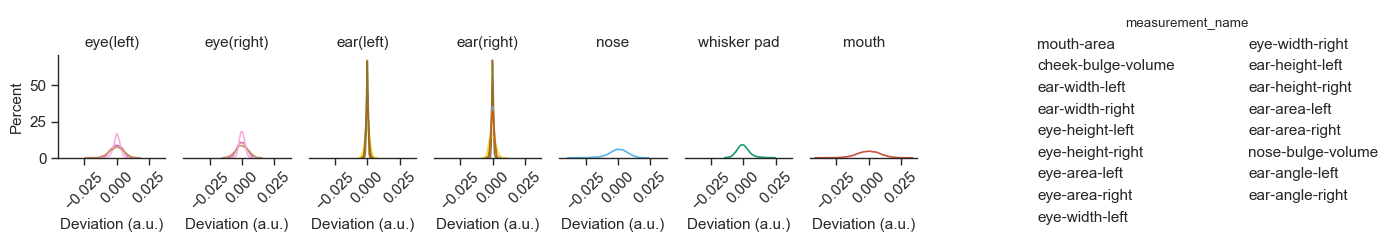

In [15]:
def plot_histogram(deviations, color, label):
    if label == "nose-bulge":
        cmap_key = "nose-bulge-volume"
    elif label == "whisker-pad-bulge":
        cmap_key = "cheek-bulge-volume"
    else:
        cmap_key = label
    sns.histplot(x=np.concatenate(deviations.values, axis=0),
                 color=MEASUREMENT_CMAP[cmap_key],
                 label=label,
                 kde=True,
                 stat="percent",
                 binwidth=0.001,
                 # hack to hide bars but keep percent y-axis
                 fill=False,
                 linewidth=0)
    # sns.kdeplot(x=np.concatenate(deviations.values, axis=0),
    #             color=MEASUREMENT_CMAP[label],
    #             label=label)

ncols = len(meas_jitter_df["region"].unique())
total_width = 2 * 5 # inches
facet_width = total_width / ncols
total_height = 2
aspect = facet_width / total_height
g = sns.FacetGrid(meas_jitter_df.query("mouse == 'B15'"),
                  col="region", hue="measurement_name",
                  col_order=REGION_ORDER,
                  aspect=aspect,
                  height=total_height,
                  margin_titles=True)
g.map(plot_histogram, "deviations_au")
g.add_legend(label_order=list(MEASUREMENT_CMAP.keys()), ncols=2)
# g.figure.suptitle("Coordinate-wise Deviation from Mean Landmark Position")
g.set_xlabels("Deviation (a.u.)")
g.set_titles(col_template="{col_name}")
g.tight_layout(w_pad=0.5)
for ax in g.axes.flat[1:]:
    sns.despine(ax=ax, left=True)
    ax.tick_params(axis="y", left=False)
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=45)

## Panel a

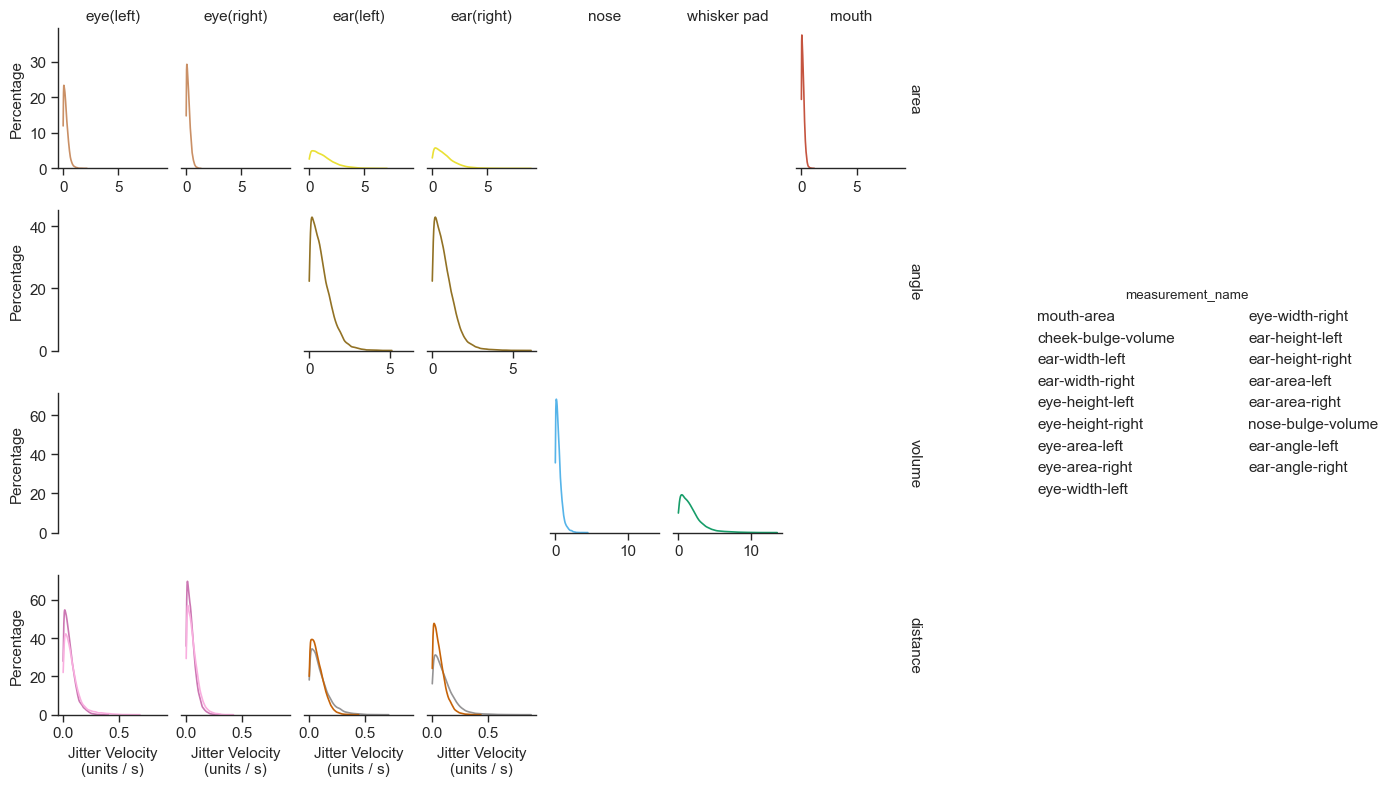

In [16]:
def plot_histogram(deviations, color, label):
    if label == "nose-bulge":
        cmap_key = "nose-bulge-volume"
    elif label == "whisker-pad-bulge":
        cmap_key = "cheek-bulge-volume"
    else:
        cmap_key = label

    if "area" in cmap_key:
        binwidth = 0.1
    elif "angle" in cmap_key:
        binwidth = 0.5
    elif "volume" in cmap_key:
        binwidth = 0.5
    else:
        binwidth = 0.05

    sns.histplot(x=np.concatenate(deviations.values, axis=0),
                 color=MEASUREMENT_CMAP[cmap_key],
                 label=label,
                 kde=True,
                 stat="percent",
                 binwidth=binwidth,
                 # hack to hide bars but keep percent y-axis
                 fill=False,
                 linewidth=0)
    # sns.kdeplot(x=np.concatenate(deviations.values, axis=0),
    #             color=MEASUREMENT_CMAP[label],
    #             label=label)

ncols = len(jitter_df["region"].unique())
total_width = 2 * 5 # inches
facet_width = total_width / ncols
total_height = 2
aspect = facet_width / total_height
g = sns.FacetGrid(meas_jitter_df.query("mouse == 'B15'"),
                  row="measurement_type", col="region", hue="measurement_name",
                  col_order=REGION_ORDER,
                  sharex="row", sharey="row",
                  aspect=aspect,
                  height=total_height,
                  margin_titles=True)
g.map(plot_histogram, "velocities")
g.add_legend(label_order=list(MEASUREMENT_CMAP.keys()), ncols=2)
g.set_titles(row_template="{row_name}", col_template="{col_name}")
# g.figure.suptitle("Coordinate-wise Deviation from Mean Landmark Position")
g.set_xlabels("Jitter Velocity\n(units / s)")
g.tight_layout(w_pad=0.5)
for i, row in enumerate(g.axes):
    for j, ax in enumerate(row):
        if j > 0:
            if ax.has_data():
                sns.despine(ax=ax, left=True)
                ax.tick_params(axis="y", left=False)
            else:
                ax.axis("off")
        else:
            ax.set_ylabel("Percentage")
            if (not ax.has_data()) and (i < (g.axes.shape[0] - 1)):
                sns.despine(ax=ax, bottom=True)
                ax.tick_params(axis="x", bottom=False, labelbottom=False)

save_figure(OUTPUT_DIR, "long-anes-c-meas-jitter-hist", g.figure)

## Panel b

/tmp/ipykernel_161388/2150551068.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, "region_rank"] = df["region"].transform(lambda x: region_order.index(x))
/tmp/ipykernel_161388/2150551068.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, "region_rank"] = df["region"].transform(lambda x: region_order.index(x))
/tmp/ipykernel_161388/2150551068.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = val

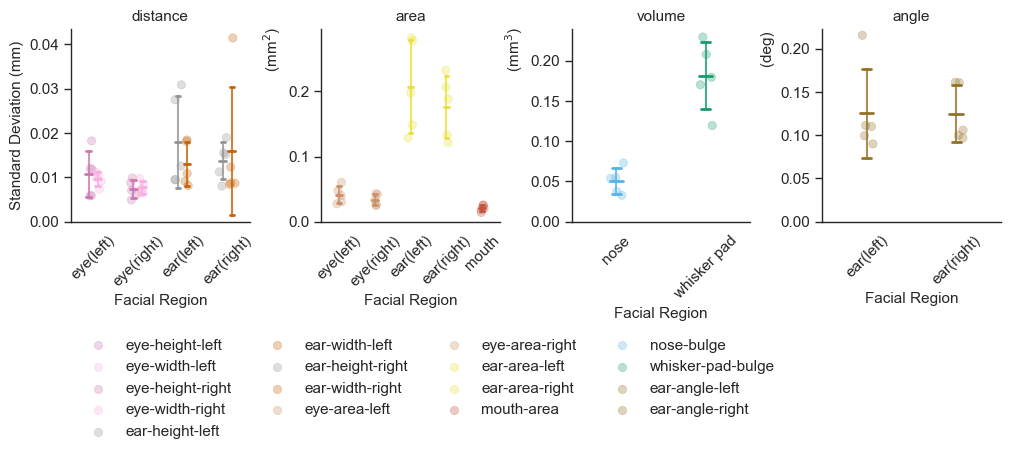

In [17]:
measurement_types = ["distance", "area", "volume", "angle"]
fig, axs = plt.subplots(ncols=len(measurement_types),
                        figsize=(12, 2.5))

for ax, measurement_type in zip(axs, measurement_types):
    # sort the data by region and compute manual dodge factors
    sub_df = meas_jitter_df.query("mouse.str.startswith('B') & "
                                  "measurement_type == @measurement_type")
    sub_df = sort_by_region(sub_df, REGION_ORDER, "measurement_name")
    hue_order = sub_df.drop_duplicates("measurement_name")["measurement_name"].values
    hue_order[hue_order == "whisker-pad-bulge"] = "cheek-bulge-volume"
    hue_order[hue_order == "nose-bulge"] = "nose-bulge-volume"

    dodges = compute_dodges(sub_df, x="region", hue="measurement_name", gap=0.1)
    dodge_shift = so.Shift(x=dodges["dodge"])
    dodges_agg = dodges.drop_duplicates("measurement_name")
    dodge_shift_agg = so.Shift(x=dodges_agg["dodge"].values)

    p = (so.Plot(sub_df, x="region", y="timeseries_stddev", color="measurement_name")
            # plot scatter of samples
            .add(so.Dot(alpha=0.3), dodge_shift, so.Jitter())
            # plot mean bar
            .add(so.Dash(linewidth=2, width=0.15), so.Agg(), dodge_shift_agg)
            # plot stddev whiskers
            .add(so.Dash(linewidth=2, width=0.1),
                so.Agg(lambda x: x.mean() + x.std(ddof=1)),
                dodge_shift_agg)
            .add(so.Dash(linewidth=2, width=0.1),
                so.Agg(lambda x: x.mean() - x.std(ddof=1)),
                dodge_shift_agg)
            # connect mean to whiskers (stddev range)
            .add(so.Range(alpha=0.8), so.Est(errorbar="sd"), dodge_shift_agg)
            .scale(y=so.Continuous().tick(upto=5))
            .theme({"axes.prop_cycle": plt.cycler(color=[MEASUREMENT_CMAP[l] for l in hue_order])})
            .label(x=None, y=None)
            .on(ax).plot())

    # sort the data by region and compute manual dodge factors
    # sub_df = meas_jitter_df.query("mouse.str.startswith('C')")
    # sub_df = sort_by_region(sub_df, REGION_ORDER, "measurement_name")
    # hue_order = sub_df.drop_duplicates("measurement_name")["measurement_name"].values

    # dodges = compute_dodges(sub_df, x="region", hue="measurement_name", gap=0.1)
    # dodge_shift = so.Shift(x=dodges["dodge"])
    # # dodges_agg = dodges.drop_duplicates("measurement_name")
    # # dodge_shift_agg = so.Shift(x=dodges_agg["dodge"].values)

    # p = (so.Plot(sub_df, x="region", y="timeseries_stddev_au", color="measurement_name")
    #         # plot scatter of samples
    #         .add(so.Dot(marker="x"), dodge_shift, legend=False)
    #         # plot mean bar
    #         # .add(so.Dash(linewidth=2, width=0.15), so.Agg(), dodge_shift_agg)
    #         # plot stddev whiskers
    #         # .add(so.Dash(linewidth=2, width=0.1),
    #         #      so.Agg(lambda x: x.mean() + x.std()),
    #         #      dodge_shift_agg)
    #         # .add(so.Dash(linewidth=2, width=0.1),
    #         #      so.Agg(lambda x: x.mean() - x.std()),
    #         #      dodge_shift_agg)
    #         # connect mean to whiskers (stddev range)
    #         # .add(so.Range(alpha=0.8), so.Est(errorbar="sd"), dodge_shift_agg)
    #         .scale(y=so.Continuous().tick(upto=5))
    #         .theme({"axes.prop_cycle": plt.cycler(color=[MEASUREMENT_CMAP[l] for l in hue_order])})
    #         .on(ax).plot())

    ax.set_title(measurement_type)
    ax.set_xlabel("Facial Region")
    ax.set_ylim(0, None)
    if measurement_type == "distance":
        ax.set_ylabel("Standard Deviation (mm)")
    elif measurement_type == "area":
        ax.set_ylabel("                                    (mm$^2$)")
    elif measurement_type == "volume":
        ax.set_ylabel("                                    (mm$^3$)")
    elif measurement_type == "angle":
        ax.set_ylabel("                                    (deg)")
    ax.tick_params(axis="x", rotation=45, bottom=False)
# hack to customize legends with seaborn objects interface
legend_dict = {}
while len(fig.legends) > 0:
    legend = fig.legends.pop(0)
    for label, handle in zip(legend.texts, legend.legend_handles):
        label_text = label.get_text()
        if label_text not in legend_dict:
            legend_dict[label_text] = handle
axs[0].legend(list(legend_dict.values()), list(legend_dict.keys()),
              ncols=4, frameon=False, loc="lower center", bbox_to_anchor=(2.0, -1.2))
fig.subplots_adjust(wspace=0.4)
sns.despine(fig)

/tmp/ipykernel_161388/2150551068.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, "region_rank"] = df["region"].transform(lambda x: region_order.index(x))
/tmp/ipykernel_161388/2150551068.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, "region_rank"] = df["region"].transform(lambda x: region_order.index(x))
/tmp/ipykernel_161388/2150551068.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = val

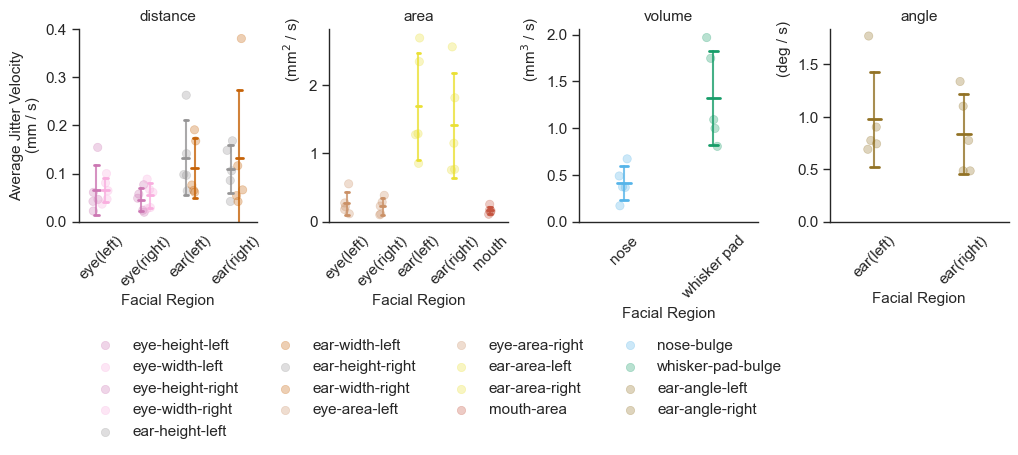

In [18]:
measurement_types = ["distance", "area", "volume", "angle"]
fig, axs = plt.subplots(ncols=len(measurement_types),
                        figsize=(12, 2.5))

for ax, measurement_type in zip(axs, measurement_types):
    # sort the data by region and compute manual dodge factors
    sub_df = meas_jitter_df.query("mouse.str.startswith('B') & "
                                  "measurement_type == @measurement_type")
    sub_df = sort_by_region(sub_df, REGION_ORDER, "measurement_name")
    hue_order = sub_df.drop_duplicates("measurement_name")["measurement_name"].values
    hue_order[hue_order == "whisker-pad-bulge"] = "cheek-bulge-volume"
    hue_order[hue_order == "nose-bulge"] = "nose-bulge-volume"

    dodges = compute_dodges(sub_df, x="region", hue="measurement_name", gap=0.1)
    dodge_shift = so.Shift(x=dodges["dodge"])
    dodges_agg = dodges.drop_duplicates("measurement_name")
    dodge_shift_agg = so.Shift(x=dodges_agg["dodge"].values)

    p = (so.Plot(sub_df, x="region", y="velocity_mean", color="measurement_name")
            # plot scatter of samples
            .add(so.Dot(alpha=0.3), dodge_shift, so.Jitter())
            # plot mean bar
            .add(so.Dash(linewidth=2, width=0.15), so.Agg(), dodge_shift_agg)
            # plot stddev whiskers
            .add(so.Dash(linewidth=2, width=0.1),
                so.Agg(lambda x: x.mean() + x.std(ddof=1)),
                dodge_shift_agg)
            .add(so.Dash(linewidth=2, width=0.1),
                so.Agg(lambda x: x.mean() - x.std(ddof=1)),
                dodge_shift_agg)
            # connect mean to whiskers (stddev range)
            .add(so.Range(alpha=0.8), so.Est(errorbar="sd"), dodge_shift_agg)
            .scale(y=so.Continuous().tick(upto=5))
            .theme({"axes.prop_cycle": plt.cycler(color=[MEASUREMENT_CMAP[l] for l in hue_order])})
            .label(x=None, y=None)
            .on(ax).plot())

    # sort the data by region and compute manual dodge factors
    # sub_df = meas_jitter_df.query("mouse.str.startswith('C')")
    # sub_df = sort_by_region(sub_df, REGION_ORDER, "measurement_name")
    # hue_order = sub_df.drop_duplicates("measurement_name")["measurement_name"].values

    # dodges = compute_dodges(sub_df, x="region", hue="measurement_name", gap=0.1)
    # dodge_shift = so.Shift(x=dodges["dodge"])
    # # dodges_agg = dodges.drop_duplicates("measurement_name")
    # # dodge_shift_agg = so.Shift(x=dodges_agg["dodge"].values)

    # p = (so.Plot(sub_df, x="region", y="timeseries_stddev_au", color="measurement_name")
    #         # plot scatter of samples
    #         .add(so.Dot(marker="x"), dodge_shift, legend=False)
    #         # plot mean bar
    #         # .add(so.Dash(linewidth=2, width=0.15), so.Agg(), dodge_shift_agg)
    #         # plot stddev whiskers
    #         # .add(so.Dash(linewidth=2, width=0.1),
    #         #      so.Agg(lambda x: x.mean() + x.std()),
    #         #      dodge_shift_agg)
    #         # .add(so.Dash(linewidth=2, width=0.1),
    #         #      so.Agg(lambda x: x.mean() - x.std()),
    #         #      dodge_shift_agg)
    #         # connect mean to whiskers (stddev range)
    #         # .add(so.Range(alpha=0.8), so.Est(errorbar="sd"), dodge_shift_agg)
    #         .scale(y=so.Continuous().tick(upto=5))
    #         .theme({"axes.prop_cycle": plt.cycler(color=[MEASUREMENT_CMAP[l] for l in hue_order])})
    #         .on(ax).plot())

    ax.set_title(measurement_type)
    ax.set_xlabel("Facial Region")
    ax.set_ylim(0, None)
    if measurement_type == "distance":
        ax.set_ylabel("Average Jitter Velocity\n(mm / s)")
    elif measurement_type == "area":
        ax.set_ylabel("                                    (mm$^2$ / s)")
    elif measurement_type == "volume":
        ax.set_ylabel("                                    (mm$^3$ / s)")
    elif measurement_type == "angle":
        ax.set_ylabel("                                    (deg / s)")
    ax.tick_params(axis="x", rotation=45, bottom=False)
# hack to customize legends with seaborn objects interface
legend_dict = {}
while len(fig.legends) > 0:
    legend = fig.legends.pop(0)
    for label, handle in zip(legend.texts, legend.legend_handles):
        label_text = label.get_text()
        if label_text not in legend_dict:
            legend_dict[label_text] = handle
axs[0].legend(list(legend_dict.values()), list(legend_dict.keys()),
              ncols=4, frameon=False, loc="lower center", bbox_to_anchor=(2.0, -1.2))
fig.subplots_adjust(wspace=0.4)
sns.despine(fig)
# save_figure(OUTPUT_DIR, "long-anes-d-jitter-summary", fig)

In [19]:
stats_df = meas_jitter_df[["mouse", "measurement_name", "velocity_mean"]].pivot(
    columns="measurement_name", index="mouse"
)
# stats_df.to_clipboard(excel=True)
stats_df

velocity_mean                                               \
measurement_name ear-angle-left ear-angle-right ear-area-left ear-area-right   
mouse                                                                          
B15                    0.774387        0.774244      1.272702       1.147856   
B20                    0.690106        0.484243      1.287329       0.766027   
B26                    0.742416        0.484719      0.852973       0.756266   
B6                     0.902213        1.101446      2.342217       2.558216   
B8                     1.770779        1.336968      2.688352       1.812845   

                                                                  \
measurement_name ear-height-left ear-height-right ear-width-left   
mouse                                                              
B15                     0.097903         0.105767       0.076136   
B20                     0.141465         0.041951       0.064943   
B26                     0.064000         0.085625       0.061058   
B6                      0.096334         0.148199       0.190943   
B8                      0.262886         0.168110       0.167798   

                                                                               \
measurement_name ear-width-right eye-area-left eye-area-right eye-height-left   
mouse                                                                           
B15                     0.066063      0.273424       0.228100        0.060872   
B20                     0.054079      0.177351       0.111799        0.042168   
B26                     0.041773      0.114733       0.100242        0.022063   
B6                      0.380735      0.219377       0.285600        0.046182   
B8                      0.116168      0.553262       0.384890        0.154349   

                                                                             \
measurement_name eye-height-right eye-width-left eye-width-right mouth-area   
mouse                                                                         
B15                      0.048701       0.080530        0.060980   0.166117   
B20                      0.023726       0.046714        0.029355   0.108113   
B26                      0.019601       0.036437        0.026838   0.139013   
B6                       0.057249       0.064351        0.066904   0.158516   
B8                       0.076767       0.099961        0.088450   0.253406   

                                               
measurement_name nose-bulge whisker-pad-bulge  
mouse                                          
B15                0.488407          1.747302  
B20                0.366553          0.997533  
B26                0.169595          0.805336  
B6                 0.372570          1.091510  
B8                 0.671673          1.969576

/tmp/ipykernel_161388/2150551068.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, "region_rank"] = df["region"].transform(lambda x: region_order.index(x))
/tmp/ipykernel_161388/2150551068.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, "region_rank"] = df["region"].transform(lambda x: region_order.index(x))
/tmp/ipykernel_161388/2150551068.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = val

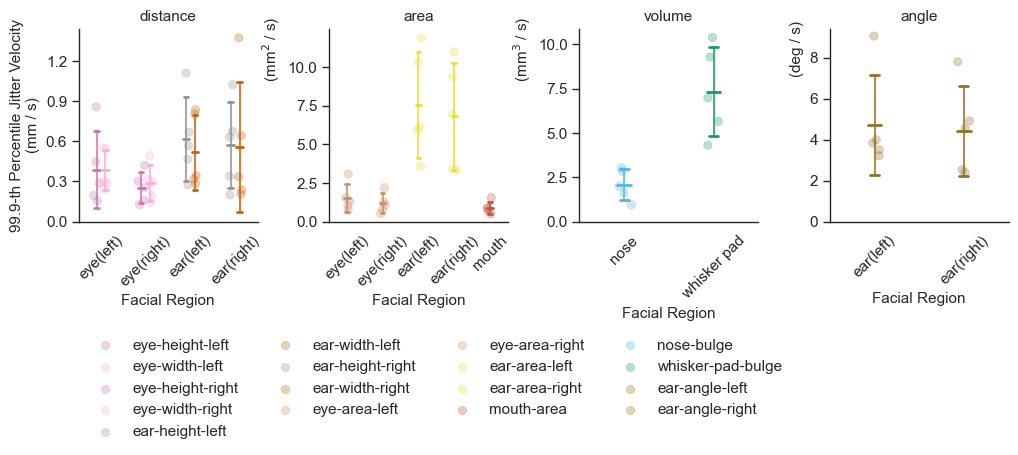

In [20]:
measurement_types = ["distance", "area", "volume", "angle"]
fig, axs = plt.subplots(ncols=len(measurement_types),
                        figsize=(12, 2.5))

for ax, measurement_type in zip(axs, measurement_types):
    # sort the data by region and compute manual dodge factors
    sub_df = meas_jitter_df.query("mouse.str.startswith('B') & "
                                  "measurement_type == @measurement_type")
    sub_df = sort_by_region(sub_df, REGION_ORDER, "measurement_name")
    hue_order = sub_df.drop_duplicates("measurement_name")["measurement_name"].values
    hue_order[hue_order == "whisker-pad-bulge"] = "cheek-bulge-volume"
    hue_order[hue_order == "nose-bulge"] = "nose-bulge-volume"

    dodges = compute_dodges(sub_df, x="region", hue="measurement_name", gap=0.1)
    dodge_shift = so.Shift(x=dodges["dodge"])
    dodges_agg = dodges.drop_duplicates("measurement_name")
    dodge_shift_agg = so.Shift(x=dodges_agg["dodge"].values)

    p = (so.Plot(sub_df, x="region", y="velocity_thresh", color="measurement_name")
            # plot scatter of samples
            .add(so.Dot(alpha=0.3), dodge_shift, so.Jitter())
            # plot mean bar
            .add(so.Dash(linewidth=2, width=0.15), so.Agg(), dodge_shift_agg)
            # plot stddev whiskers
            .add(so.Dash(linewidth=2, width=0.1),
                so.Agg(lambda x: x.mean() + x.std(ddof=1)),
                dodge_shift_agg)
            .add(so.Dash(linewidth=2, width=0.1),
                so.Agg(lambda x: x.mean() - x.std(ddof=1)),
                dodge_shift_agg)
            # connect mean to whiskers (stddev range)
            .add(so.Range(alpha=0.8), so.Est(errorbar="sd"), dodge_shift_agg)
            .scale(y=so.Continuous().tick(upto=5))
            .theme({"axes.prop_cycle": plt.cycler(color=[MEASUREMENT_CMAP[l] for l in hue_order])})
            .label(x=None, y=None)
            .on(ax).plot())

    # sort the data by region and compute manual dodge factors
    # sub_df = meas_jitter_df.query("mouse.str.startswith('C')")
    # sub_df = sort_by_region(sub_df, REGION_ORDER, "measurement_name")
    # hue_order = sub_df.drop_duplicates("measurement_name")["measurement_name"].values

    # dodges = compute_dodges(sub_df, x="region", hue="measurement_name", gap=0.1)
    # dodge_shift = so.Shift(x=dodges["dodge"])
    # # dodges_agg = dodges.drop_duplicates("measurement_name")
    # # dodge_shift_agg = so.Shift(x=dodges_agg["dodge"].values)

    # p = (so.Plot(sub_df, x="region", y="timeseries_stddev_au", color="measurement_name")
    #         # plot scatter of samples
    #         .add(so.Dot(marker="x"), dodge_shift, legend=False)
    #         # plot mean bar
    #         # .add(so.Dash(linewidth=2, width=0.15), so.Agg(), dodge_shift_agg)
    #         # plot stddev whiskers
    #         # .add(so.Dash(linewidth=2, width=0.1),
    #         #      so.Agg(lambda x: x.mean() + x.std()),
    #         #      dodge_shift_agg)
    #         # .add(so.Dash(linewidth=2, width=0.1),
    #         #      so.Agg(lambda x: x.mean() - x.std()),
    #         #      dodge_shift_agg)
    #         # connect mean to whiskers (stddev range)
    #         # .add(so.Range(alpha=0.8), so.Est(errorbar="sd"), dodge_shift_agg)
    #         .scale(y=so.Continuous().tick(upto=5))
    #         .theme({"axes.prop_cycle": plt.cycler(color=[MEASUREMENT_CMAP[l] for l in hue_order])})
    #         .on(ax).plot())

    ax.set_title(measurement_type)
    ax.set_xlabel("Facial Region")
    ax.set_ylim(0, None)
    if measurement_type == "distance":
        ax.set_ylabel("99.9-th Percentile Jitter Velocity\n(mm / s)")
    elif measurement_type == "area":
        ax.set_ylabel("                                    (mm$^2$ / s)")
    elif measurement_type == "volume":
        ax.set_ylabel("                                    (mm$^3$ / s)")
    elif measurement_type == "angle":
        ax.set_ylabel("                                    (deg / s)")
    ax.tick_params(axis="x", rotation=45, bottom=False)
# hack to customize legends with seaborn objects interface
legend_dict = {}
while len(fig.legends) > 0:
    legend = fig.legends.pop(0)
    for label, handle in zip(legend.texts, legend.legend_handles):
        label_text = label.get_text()
        if label_text not in legend_dict:
            legend_dict[label_text] = handle
axs[0].legend(list(legend_dict.values()), list(legend_dict.keys()),
              ncols=4, frameon=False, loc="lower center", bbox_to_anchor=(2.0, -1.2))
fig.subplots_adjust(wspace=0.4)
sns.despine(fig)
# save_figure(OUTPUT_DIR, "long-anes-c-meas-jitter-summary", fig)

## Panel c

/tmp/ipykernel_161388/2150551068.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, "region_rank"] = df["region"].transform(lambda x: region_order.index(x))
/tmp/ipykernel_161388/2150551068.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, "region_rank"] = df["region"].transform(lambda x: region_order.index(x))
/tmp/ipykernel_161388/2150551068.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = val

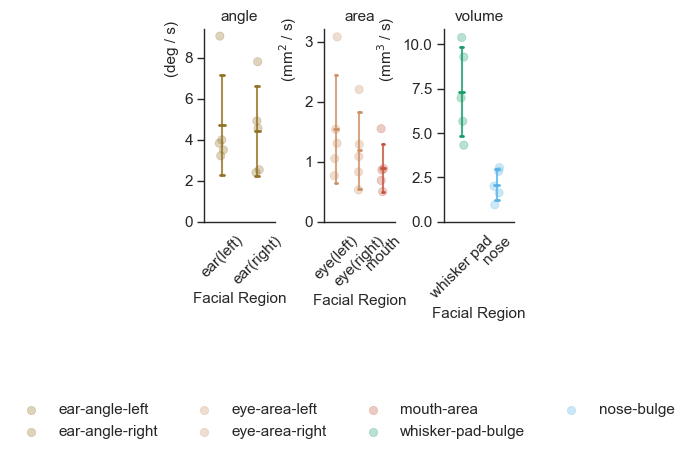

In [21]:
measurement_types = ["angle", "area", "volume"]
region_order = ["ear(left)", "ear(right)",
                "eye(left)", "eye(right)",
                "mouth", "whisker pad", "nose"]
measurements = ["ear-angle-left", "ear-angle-right",
                "eye-area-left", "eye-area-right",
                "mouth-area", "whisker-pad-bulge", "nose-bulge"]
fig, axs = plt.subplots(ncols=len(measurement_types),
                        figsize=(4, 2.5))

for ax, measurement_type in zip(axs, measurement_types):
    # sort the data by region and compute manual dodge factors
    sub_df = meas_jitter_df.query("mouse.str.startswith('B') & "
                                  "measurement_type == @measurement_type & "
                                  "measurement_name in @measurements")
    sub_df = sort_by_region(sub_df, region_order, "measurement_name")
    hue_order = sub_df.drop_duplicates("measurement_name")["measurement_name"].values
    hue_order[hue_order == "whisker-pad-bulge"] = "cheek-bulge-volume"
    hue_order[hue_order == "nose-bulge"] = "nose-bulge-volume"

    dodges = compute_dodges(sub_df, x="region", hue="measurement_name", gap=0.1)
    dodge_shift = so.Shift(x=dodges["dodge"])
    dodges_agg = dodges.drop_duplicates("measurement_name")
    dodge_shift_agg = so.Shift(x=dodges_agg["dodge"].values)

    p = (so.Plot(sub_df, x="region", y="velocity_thresh", color="measurement_name")
            # plot scatter of samples
            .add(so.Dot(alpha=0.3), dodge_shift, so.Jitter())
            # plot mean bar
            .add(so.Dash(linewidth=2, width=0.15), so.Agg(), dodge_shift_agg)
            # plot stddev whiskers
            .add(so.Dash(linewidth=2, width=0.1),
                so.Agg(lambda x: x.mean() + x.std(ddof=1)),
                dodge_shift_agg)
            .add(so.Dash(linewidth=2, width=0.1),
                so.Agg(lambda x: x.mean() - x.std(ddof=1)),
                dodge_shift_agg)
            # connect mean to whiskers (stddev range)
            .add(so.Range(alpha=0.8), so.Est(errorbar="sd"), dodge_shift_agg)
            .scale(y=so.Continuous().tick(upto=5))
            .theme({"axes.prop_cycle": plt.cycler(color=[MEASUREMENT_CMAP[l] for l in hue_order])})
            .label(x=None, y=None)
            .on(ax).plot())

    # sort the data by region and compute manual dodge factors
    # sub_df = meas_jitter_df.query("mouse.str.startswith('C')")
    # sub_df = sort_by_region(sub_df, REGION_ORDER, "measurement_name")
    # hue_order = sub_df.drop_duplicates("measurement_name")["measurement_name"].values

    # dodges = compute_dodges(sub_df, x="region", hue="measurement_name", gap=0.1)
    # dodge_shift = so.Shift(x=dodges["dodge"])
    # # dodges_agg = dodges.drop_duplicates("measurement_name")
    # # dodge_shift_agg = so.Shift(x=dodges_agg["dodge"].values)

    # p = (so.Plot(sub_df, x="region", y="timeseries_stddev_au", color="measurement_name")
    #         # plot scatter of samples
    #         .add(so.Dot(marker="x"), dodge_shift, legend=False)
    #         # plot mean bar
    #         # .add(so.Dash(linewidth=2, width=0.15), so.Agg(), dodge_shift_agg)
    #         # plot stddev whiskers
    #         # .add(so.Dash(linewidth=2, width=0.1),
    #         #      so.Agg(lambda x: x.mean() + x.std()),
    #         #      dodge_shift_agg)
    #         # .add(so.Dash(linewidth=2, width=0.1),
    #         #      so.Agg(lambda x: x.mean() - x.std()),
    #         #      dodge_shift_agg)
    #         # connect mean to whiskers (stddev range)
    #         # .add(so.Range(alpha=0.8), so.Est(errorbar="sd"), dodge_shift_agg)
    #         .scale(y=so.Continuous().tick(upto=5))
    #         .theme({"axes.prop_cycle": plt.cycler(color=[MEASUREMENT_CMAP[l] for l in hue_order])})
    #         .on(ax).plot())

    ax.set_title(measurement_type)
    ax.set_xlabel("Facial Region")
    ax.set_ylim(0, None)
    if measurement_type == "distance":
        ax.set_ylabel("99.9-th Percentile Jitter Velocity\n(mm / s)")
    elif measurement_type == "area":
        ax.set_ylabel("                                    (mm$^2$ / s)")
    elif measurement_type == "volume":
        ax.set_ylabel("                                    (mm$^3$ / s)")
    elif measurement_type == "angle":
        ax.set_ylabel("                                    (deg / s)")
    ax.tick_params(axis="x", rotation=45, bottom=False)
# hack to customize legends with seaborn objects interface
legend_dict = {}
while len(fig.legends) > 0:
    legend = fig.legends.pop(0)
    for label, handle in zip(legend.texts, legend.legend_handles):
        label_text = label.get_text()
        if label_text not in legend_dict:
            legend_dict[label_text] = handle
axs[0].legend(list(legend_dict.values()), list(legend_dict.keys()),
              ncols=4, frameon=False, loc="lower center", bbox_to_anchor=(2.0, -1.2))
fig.subplots_adjust(wspace=0.7)
sns.despine(fig)
save_figure(OUTPUT_DIR, "long-anes-c-meas-jitter-summary", fig)

In [22]:
stats_df = meas_jitter_df[["mouse", "measurement_name", "velocity_thresh"]].pivot(
    columns="measurement_name", index="mouse"
)
# stats_df.to_clipboard(excel=True)
stats_df

velocity_thresh                                               \
measurement_name  ear-angle-left ear-angle-right ear-area-left ear-area-right   
mouse                                                                           
B15                     3.989220        4.544466      5.899598       6.943849   
B20                     3.209807        2.397232      6.130741       3.335868   
B26                     3.497174        2.528076      3.592760       3.426746   
B6                      3.825434        4.909785     10.319672      10.971192   
B8                      9.044138        7.794987     11.871332       9.349499   

                                                                  \
measurement_name ear-height-left ear-height-right ear-width-left   
mouse                                                              
B15                     0.567341         0.674410       0.343834   
B20                     0.667693         0.199455       0.318253   
B26                     0.275300         0.338795       0.283326   
B6                      0.466896         0.632102       0.804609   
B8                      1.109744         1.022390       0.835279   

                                                                               \
measurement_name ear-width-right eye-area-left eye-area-right eye-height-left   
mouse                                                                           
B15                     0.336514      1.537922       1.085392        0.287527   
B20                     0.237104      1.303992       0.827560        0.449564   
B26                     0.205986      0.765593       0.528353        0.155605   
B6                      1.373006      1.049404       1.287183        0.195077   
B8                      0.642763      3.077325       2.200306        0.857314   

                                                                             \
measurement_name eye-height-right eye-width-left eye-width-right mouth-area   
mouse                                                                         
B15                      0.254322       0.552561        0.318860   0.883829   
B20                      0.160859       0.287319        0.195266   0.499152   
B26                      0.127375       0.240037        0.141733   0.859674   
B6                       0.302888       0.304569        0.294937   0.685799   
B8                       0.420650       0.547262        0.494092   1.547510   

                                               
measurement_name nose-bulge whisker-pad-bulge  
mouse                                          
B15                3.046029         10.394482  
B20                2.000946          6.983337  
B26                0.949646          4.316286  
B6                 1.627484          5.662381  
B8                 2.842406          9.293426

In [23]:
# meas_jitter_df.to_pickle(MEAS_DATA_CACHE)